# Exploratory Data Analysis (EDA) on Obesity dataset
## DATA LOADING & CLEANING
In the first phase of the assignment, we load the dataset, determine how many variables and observations we have available, and understand their nature.<br> We also check for missing values and then look for a solution to the problem.
### Importing libraries
let us import the libraries necessary for the code to function correctly

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 

## Data Loading
We load the dataset and display the first few rows:

In [2]:
dataset = pd.read_csv("Obesity.csv")
display(dataset.head())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Dataset size
Now let's view the number of observations and variables present:

In [3]:
print(f"\n The dataset contains {dataset.shape[0]} observations and {dataset.shape[1]} variables.\n")


 The dataset contains 2114 observations and 17 variables.



We list the variables present, showing their type:

In [4]:
display(dataset.dtypes)

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

In [5]:
var_numeriche = dataset.select_dtypes(include=["float64"]).columns
var_categoriche = dataset.select_dtypes(exclude=["float64"]).columns
print(f"\n Numeric variables: {list(var_numeriche)} \n")
print(f"\n Categorical variables: {list(var_categoriche)} \n")


 Numeric variables: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'] 


 Categorical variables: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad'] 



It is possible to divide numeric variables into: **Continuous** and **Discrete**:<br><br>
**CONTINOUS**
1. Age
2. Height
3. Weight
<br><br>

**DISCRETE**
1. FCVC (1,2,3)
2. NCP (1,2,3,4)
3. CH2O (1,2,3)
4. FAF (0,1,2,3)
5. TUE (0,1,2)

<br><br>

We can further subdivide categorical variables into: **Nominals** e **Ordinals**: <br><br>
**NOMINALS**
1. Gender (Male/Female)

2. family_history_with_overweight (yes/no)

3. FAVC (yes/no)

4. SMOKE (yes/no)

5. SCC (yes/no)

6. MTRANS (Public_Transportation, Automobile, Walking, Motorbike, Bike) <br><br>

**ORDINALS**

1. CAEC (no, Sometimes, Frequently, Always)

2. CALC (no, Sometimes, Frequently, Always)

3. NObeyesdad (Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III) (**Target Variable**)

For convenience, we have chosen to rename some of the variables in order to facilitate operations.

In [6]:
dataset.rename(columns={"FAVC": "High_Caloric_Food", 
                        "FCVC": "Vegetable_Consumption", 
                        "NCP": "Main_Meals_Per_Day", 
                        "CAEC": "Food_Between_Meals", 
                        "CH2O": "Water_Intake", 
                        "SCC": "Calorie_Monitoring", 
                        "FAF": "Physical_Activity_Frequency", 
                        "TUE": "Tech_use_Time", 
                        "CALC": "Alcohol_Consumption", 
                        "MTRANS": "Transport_Mode", 
                        "NObeyesdad": "Obesity_Level",}, inplace=True)

var_numeriche = dataset.select_dtypes(include=["float64"]).columns
var_categoriche = dataset.select_dtypes(exclude=["float64"]).columns

print(f"\n Numerical variables : {list(var_numeriche)} \n")
print(f"\n Categorical variables: {list(var_categoriche)} \n")


 Numerical variables : ['Age', 'Height', 'Weight', 'Vegetable_Consumption', 'Main_Meals_Per_Day', 'Water_Intake', 'Physical_Activity_Frequency', 'Tech_use_Time'] 


 Categorical variables: ['Gender', 'family_history_with_overweight', 'High_Caloric_Food', 'Food_Between_Meals', 'SMOKE', 'Calorie_Monitoring', 'Alcohol_Consumption', 'Transport_Mode', 'Obesity_Level'] 



Following some inconsistencies found between the numerical values in the dataset, we cleaned the data to ensure greater accuracy. <br>
First, we standardised the unit of measurement for height to centimetres rather than metres to avoid potential approximation errors. <br>
Next, we rounded all numerical values. The changes made are detailed below.

In [7]:
dataset["Height"] *= 100
dataset[var_numeriche] = dataset[var_numeriche].round().astype(int)
display(dataset.head())

,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level
0,Female,21,162,64,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,152,56,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,180,77,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,180,87,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,178,90,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


### Missing Values
We check for missing values within the data for each variable:

In [8]:
print("\nMissing values for each variable\n")
missing_values = dataset.isna().sum()
display(missing_values)


Missing values for each variable



Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
High_Caloric_Food                 0
Vegetable_Consumption             0
Main_Meals_Per_Day                0
Food_Between_Meals                0
SMOKE                             0
Water_Intake                      0
Calorie_Monitoring                0
Physical_Activity_Frequency       0
Tech_use_Time                     0
Alcohol_Consumption               5
Transport_Mode                    0
Obesity_Level                     1
dtype: int64

In [9]:
missing_values_percent = ((missing_values/len(dataset))*100).round(2)
missing_values_table = pd.DataFrame({"Missing Values": missing_values, "%": missing_values_percent})
display(missing_values_table[missing_values_table["Missing Values"] > 0])

,Missing Values,%
Alcohol_Consumption,5,0.24
Obesity_Level,1,0.05


We can see that there are five missing values relating to alcohol consumption and only one missing value relating to obesity levels. <br> Let's see which row they correspond to: 

In [10]:
print("\nMissing values relating to alcohol consumption:\n")
dataset[dataset["Alcohol_Consumption"].isna()] 


Missing values relating to alcohol consumption:



,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level
13,Male,41,180,99,no,yes,2,3,Sometimes,no,2,no,2,1,NaN,Automobile,Obesity_Type_I
94,Female,24,160,48,no,yes,3,3,Sometimes,no,2,no,2,0,NaN,Public_Transportation,Normal_Weight
162,Female,21,163,60,yes,yes,3,3,Always,yes,2,no,2,0,NaN,Public_Transportation,Normal_Weight
278,Female,32,157,57,yes,yes,3,3,Sometimes,no,2,no,0,0,NaN,Automobile,Normal_Weight
463,Male,17,180,68,yes,no,2,3,Sometimes,no,1,no,2,1,NaN,Public_Transportation,Normal_Weight


In [11]:
print("\n Missing values referring to obesity level\n")
dataset[dataset["Obesity_Level"].isna()] 


 Missing values referring to obesity level



,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level
376,Female,36,158,60,yes,no,3,3,Sometimes,no,1,no,2,0,Sometimes,Automobile,NaN


### Handling missing values
During the previous phase we noticed the absence of 5 observations for the variable relating to alcohol consumption and 1 observation for the variable relating to obesity levels, both of which are categorical. <br>
These represent approximately 0.3% of the entire dataset, so we can say that we can continue to operate by removing the missing values, since continuing with mode-based imputation would result in a high level of complexity that would not benefit the analysis. <br> We could also say that with the imputation of missing values, the risk of introducing a bias, albeit certainly irrelevant, outweighs the benefit of doing so.

In [12]:
dataset_clean = dataset.dropna()
missing_values = dataset_clean.isna().sum()
display(missing_values)

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
High_Caloric_Food                 0
Vegetable_Consumption             0
Main_Meals_Per_Day                0
Food_Between_Meals                0
SMOKE                             0
Water_Intake                      0
Calorie_Monitoring                0
Physical_Activity_Frequency       0
Tech_use_Time                     0
Alcohol_Consumption               0
Transport_Mode                    0
Obesity_Level                     0
dtype: int64

In [13]:
print("Impact Analysis of removing missing values\n")

# Original dataset vs. cleaned dataset
original_shape = dataset.shape
clean_shape = dataset_clean.shape

print(f"Original dataset: {original_shape[0]} observations")
print(f"Clean dataset: {clean_shape[0]} observations")
print(f"Removed: {original_shape[0] - clean_shape[0]} ({((original_shape[0] - clean_shape[0])/original_shape[0])*100:.2f}%)\n")

Impact Analysis of removing missing values

Original dataset: 2114 observations
Clean dataset: 2108 observations
Removed: 6 (0.28%)



## Univariate Data Description 
We perform a statistical analysis that examines and summarises the characteristics of each variable individually, using measures of central tendency, dispersion and distribution.
<br>
### Descriptive Statistics
Let's start by calculating the main descriptive statistics for the cleaned dataset. <br>
For numerical variables, the following were calculated: <br>
1. Number of non-null observations
2. Mean
3. Standard Deviation
4. Minimum value
5. First quartile (Q1)
6. Median - Second quartile (Q2)
7. Third quartile (Q3)
8. Maximum Value
9. Skewness
10. Kurtosis

As regards categorical variables: <br>
1. Number of non-null observations
2. Number of unique categories
3. Most frequent category
4. Frequency of the most frequent category

In [21]:
var_num = dataset_clean.select_dtypes(include=[np.number]).columns
var_cat = dataset_clean.select_dtypes(include=["object"]).columns

discrete_ordinal_vars = [ 'Vegetable_Consumption', 'Water_Intake', 'Tech_use_Time']

var_num = [col for col in var_numeriche if col not in discrete_ordinal_vars]
print("Numeric Variables")
print(var_num)
print("\nDiscrete Ordinal Variables")
print(discrete_ordinal_vars)

Numeric Variables
['Age', 'Height', 'Weight', 'Main_Meals_Per_Day', 'Physical_Activity_Frequency']

Discrete Ordinal Variables
['Vegetable_Consumption', 'Water_Intake', 'Tech_use_Time']


SPIEGAZIONE SEPARAZIONE

In [22]:
print("\nDescriptive statistics relating to numerical variables: \n")
stats_n = dataset_clean[var_num].describe()
stats_n.rename(index={"50%": "median"}, inplace=True)
stats_n.loc["skewness"] = dataset_clean.skew(numeric_only=True)
stats_n.loc["kurtosis"] = dataset_clean.kurt(numeric_only=True)
stats_n = stats_n.round(2)
display(stats_n)


Descriptive statistics relating to numerical variables: 



,Age,Height,Weight,Main_Meals_Per_Day,Physical_Activity_Frequency
count,2108.00,2108.00,2108.00,2108.00,2108.00
mean,24.30,170.17,86.61,2.69,1.01
std,6.34,9.33,26.20,0.81,0.90
min,14.00,145.00,39.00,1.00,0.00
25%,20.00,163.00,66.00,3.00,0.00
median,23.00,170.00,83.00,3.00,1.00
75%,26.00,177.00,107.25,3.00,2.00
max,61.00,198.00,173.00,4.00,3.00
skewness,1.53,-0.01,0.25,-1.06,0.46
kurtosis,2.84,-0.56,-0.70,0.37,-0.71


Osservazioni
<ul>
    <li><b>Age:</b> La popolazione risulta abbastanza giovane. Questo viene evidenziato ulteriormente dai valori della skewness e della kurtosis, che indicano una maggiore presenza di persone giovani.</li> 
    <li><b>Height:</b> L'altezza media è di circa 170 cm.  </li> 
    <li><b>Weight:</b></li>
    <li><b>Main_Meals_Per_Day:</b></li>
    <li><b>Physical_Activity_Frequency:</b></li>
    
</ul>

In [26]:
print("\nDescriptive Statistics for Discrete Ordinal Variables: \n")
stats_d = pd.DataFrame({
    'median': dataset_clean[discrete_ordinal_vars].median(),
    'mode': dataset_clean[discrete_ordinal_vars].mode().iloc[0]
})

display(stats_d.T)


Descriptive Statistics for Discrete Ordinal Variables: 



,Vegetable_Consumption,Water_Intake,Tech_use_Time
median,2.0,2.0,1.0
mode,2.0,2.0,0.0


In [30]:
print("\nDescriptive Statistics for Categorical Variables: \n")
stats_c = dataset_clean[var_cat].describe()
stats_c.rename(index={"top": "mode"}, inplace=True)
stats_c = stats_c.round(2)
display(stats_c)


Descriptive Statistics for Categorical Variables: 



,Gender,family_history_with_overweight,High_Caloric_Food,Food_Between_Meals,SMOKE,Calorie_Monitoring,Alcohol_Consumption,Transport_Mode,Obesity_Level
count,2108,2108,2108,2108,2108,2108,2108,2108,2108
unique,2,2,2,4,2,2,4,5,7
mode,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1067,1722,1864,1763,2065,2012,1399,1579,350


In [41]:
print("\nFrequency tables: \n")
list(var_cat)
for var in (discrete_ordinal_vars + list(var_cat)):
    freq = dataset_clean[var].value_counts()
    perc = dataset_clean[var].value_counts(normalize=True) * 100

    table = pd.DataFrame({
        "Frequency": freq,
        "Percentage (%)": perc.round(2)
    })

    display(table)
    print("\n")


Frequency tables: 



,Frequency,Percentage (%)
Vegetable_Consumption,,
2,1011,47.96
3,993,47.11
1,104,4.93


,Frequency,Percentage (%)
Water_Intake,,
2,1108,52.56
3,516,24.48
1,484,22.96


,Frequency,Percentage (%)
Tech_use_Time,,
0,948,44.97
1,916,43.45
2,244,11.57


,Frequency,Percentage (%)
Gender,,
Male,1067,50.62
Female,1041,49.38


...

,Frequency,Percentage (%)
SMOKE,,
no,2065,97.96
yes,43,2.04


,Frequency,Percentage (%)
Calorie_Monitoring,,
no,2012,95.45
yes,96,4.55


,Frequency,Percentage (%)
Alcohol_Consumption,,
Sometimes,1399,66.37
no,639,30.31
Frequently,69,3.27
Always,1,0.05


,Frequency,Percentage (%)
Transport_Mode,,
Public_Transportation,1579,74.91
Automobile,455,21.58
Walking,56,2.66
Motorbike,11,0.52
Bike,7,0.33


,Frequency,Percentage (%)
Obesity_Level,,
Obesity_Type_I,350,16.60
Obesity_Type_III,324,15.37
Obesity_Type_II,297,14.09
Overweight_Level_I,291,13.80
Overweight_Level_II,290,13.76
Normal_Weight,282,13.38
Insufficient_Weight,274,13.00



 Distributions of numerical variables: 



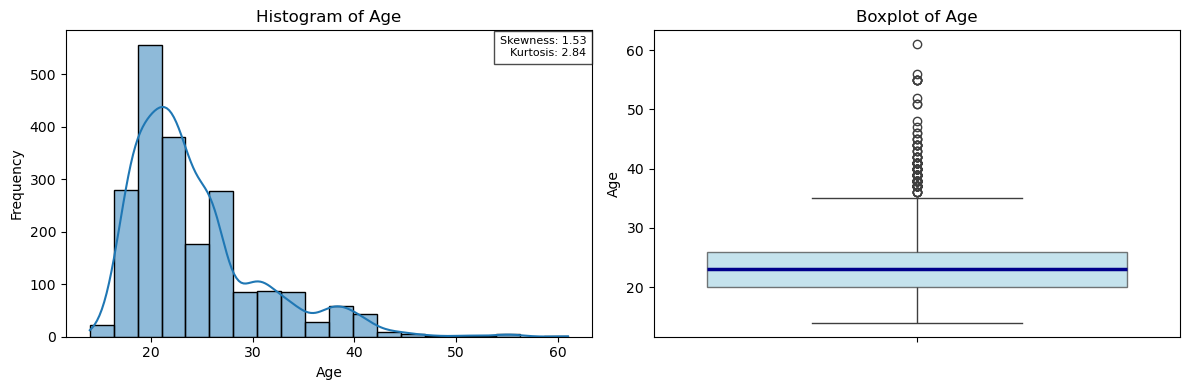

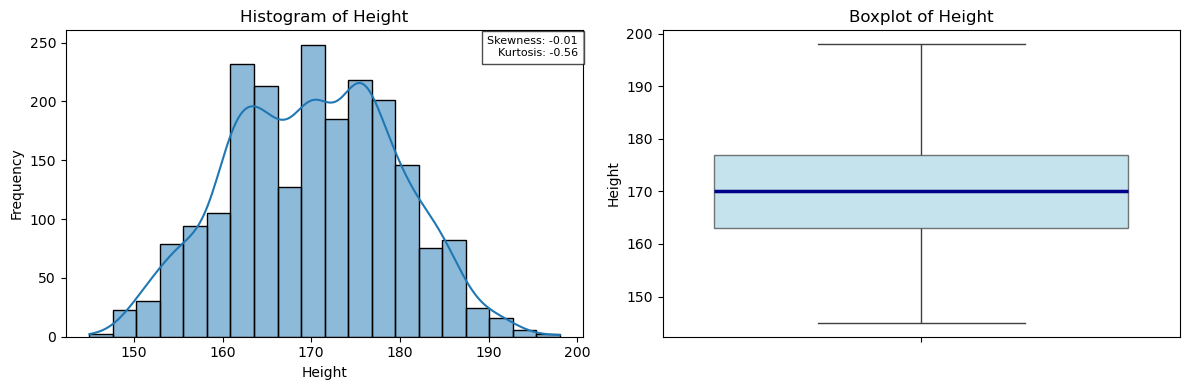

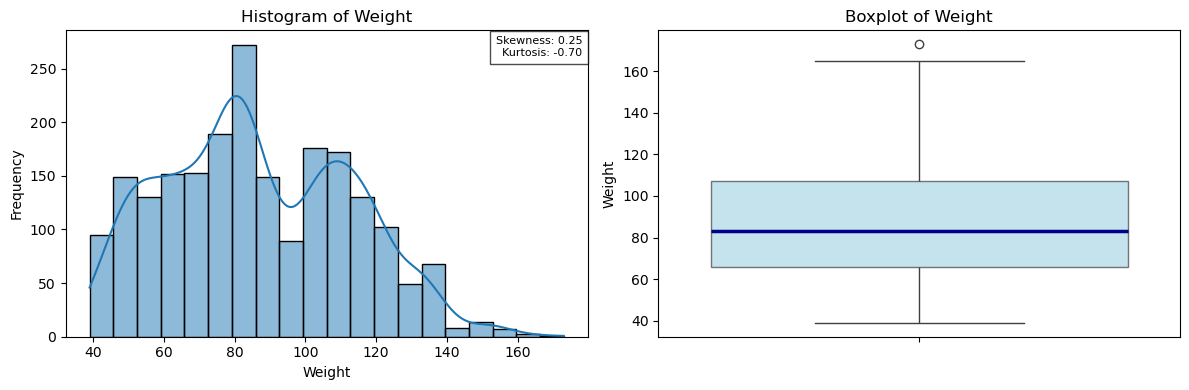

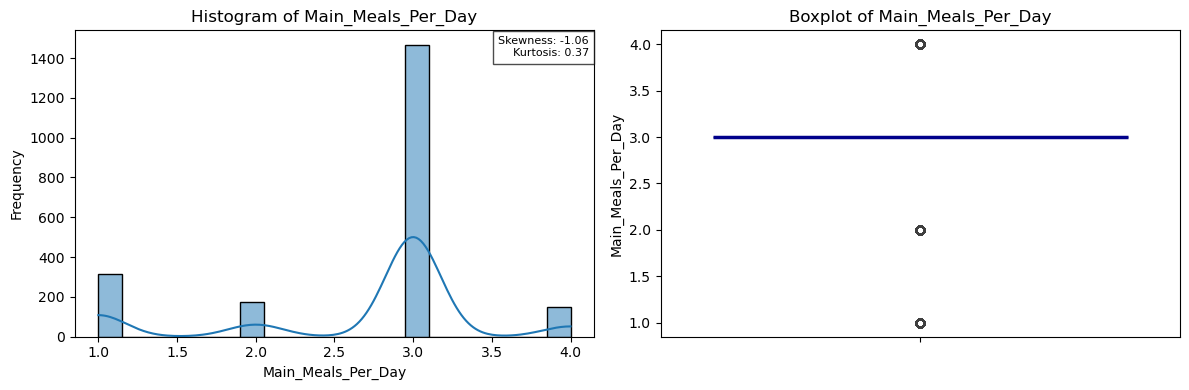

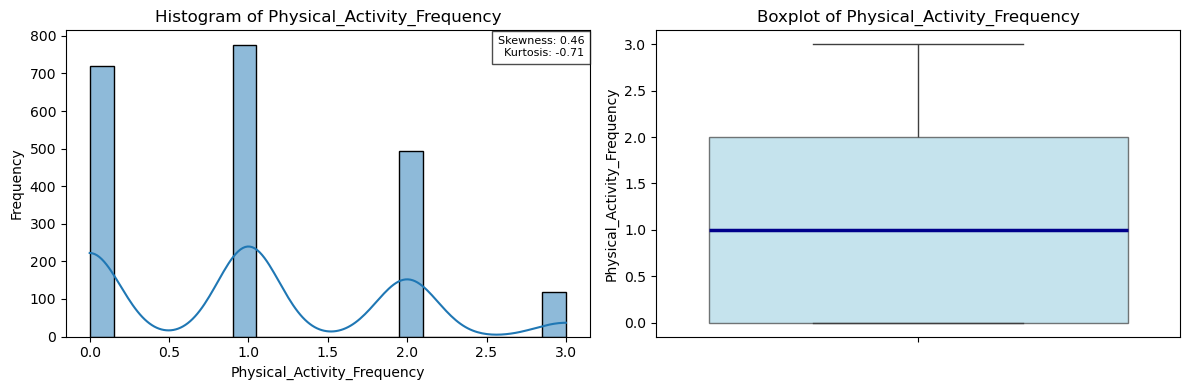

In [42]:
print("\n Distributions of numerical variables: \n")

for var in var_num:
    skew_val = dataset_clean[var].skew()
    kurt_val = dataset_clean[var].kurt()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # histogram
    sns.histplot(dataset_clean[var], kde=True, bins=20, ax=axes[0], )
    axes[0].set_title(f"Histogram of {var}")
    axes[0].set_xlabel(var)
    axes[0].set_ylabel("Frequency")

    # skewness + kurtosis 
    axes[0].text(
        0.99, 0.98,
        f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
        ha="right", va="top",
        transform=axes[0].transAxes,
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
    )

    # boxplot
    sns.boxplot(y=dataset_clean[var], ax=axes[1], boxprops=dict(facecolor="lightblue", alpha=0.7), medianprops=dict(color="darkblue", linewidth=2.5))
    axes[1].set_title(f"Boxplot of {var}")
    axes[1].set_ylabel(var)

    plt.tight_layout()
    plt.show()


 Distributions of categorical variables: 



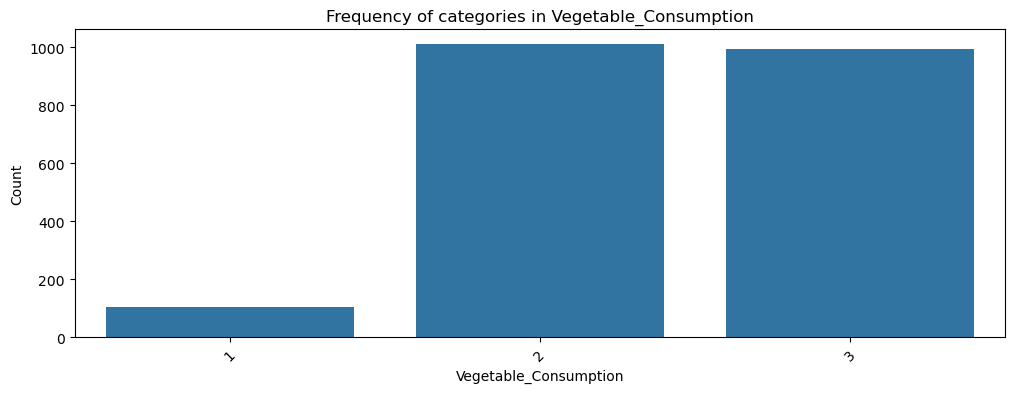

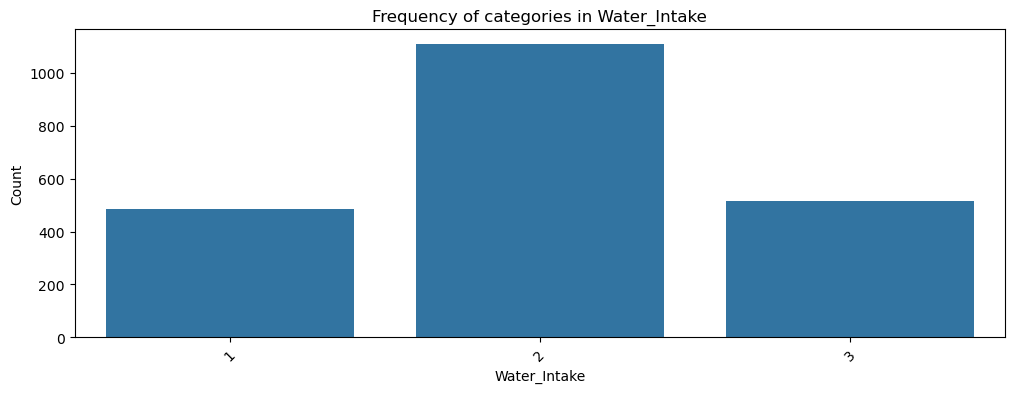

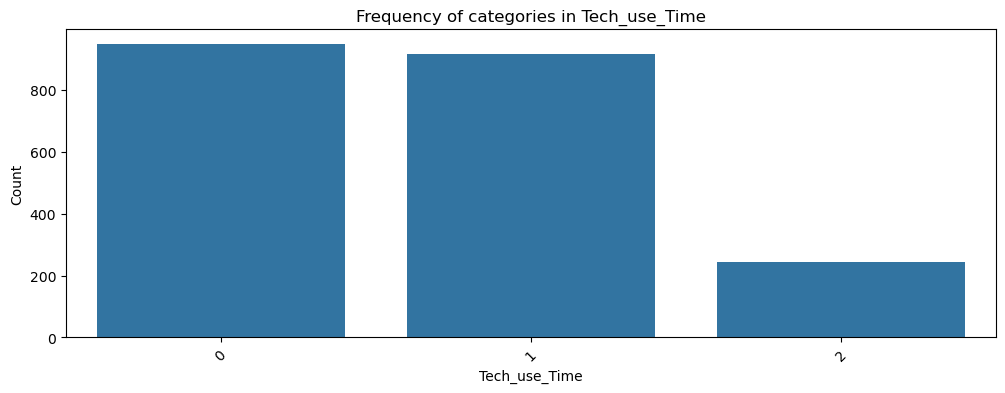

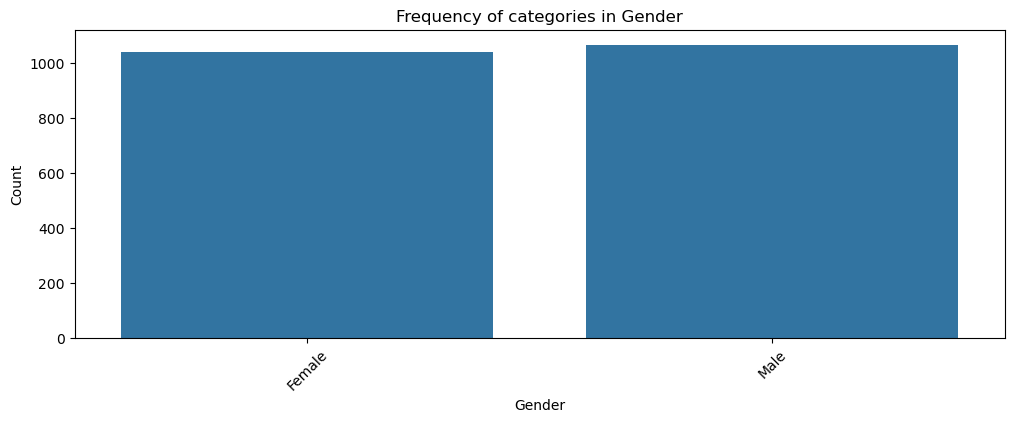

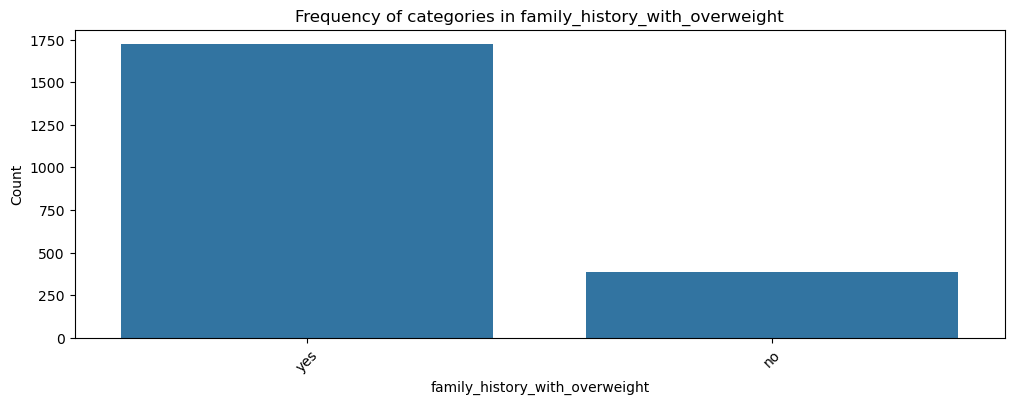

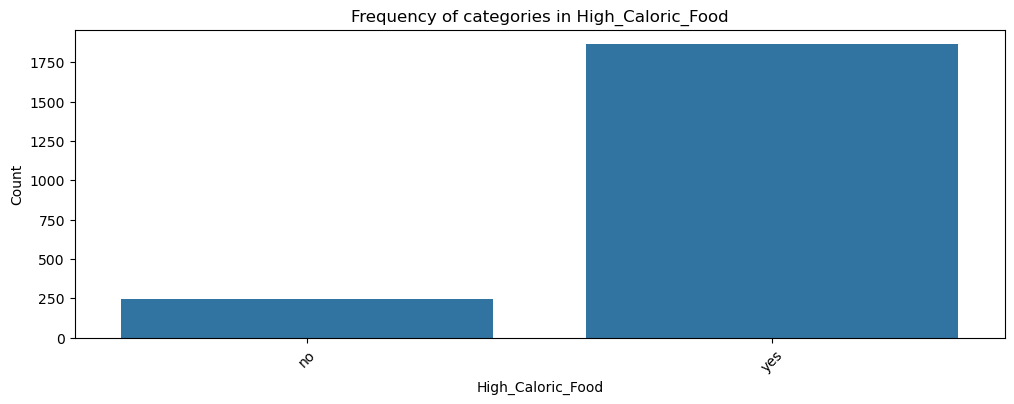

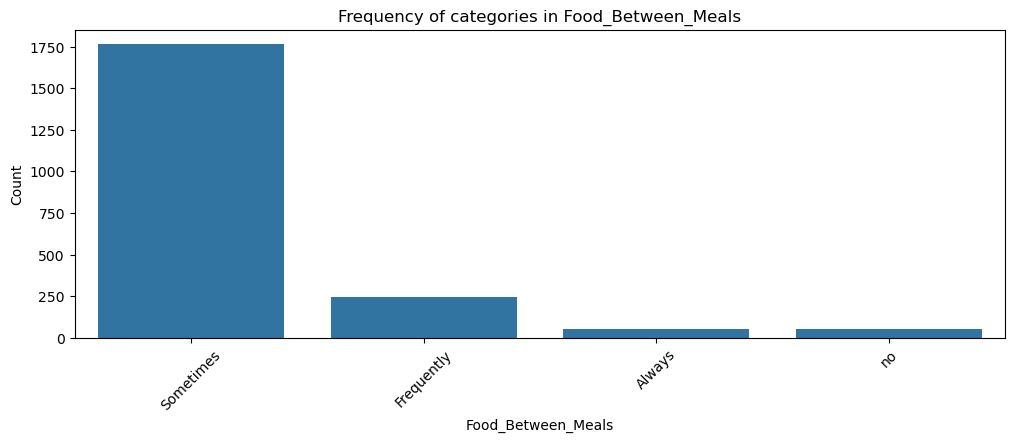

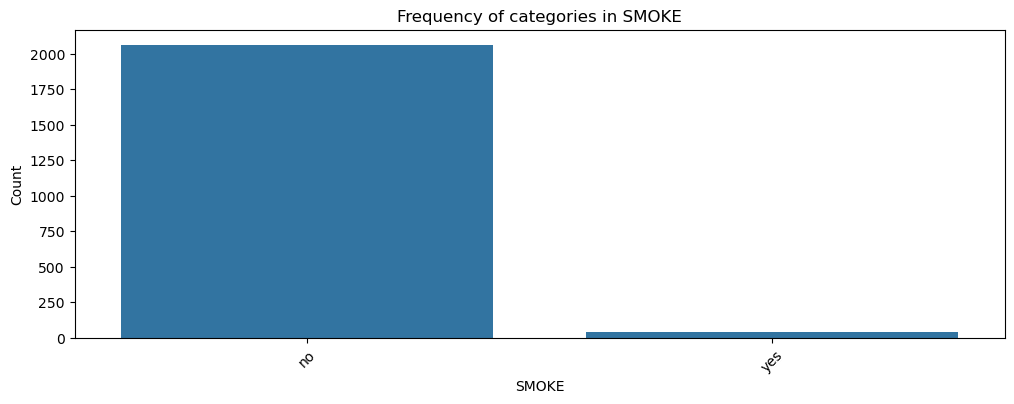

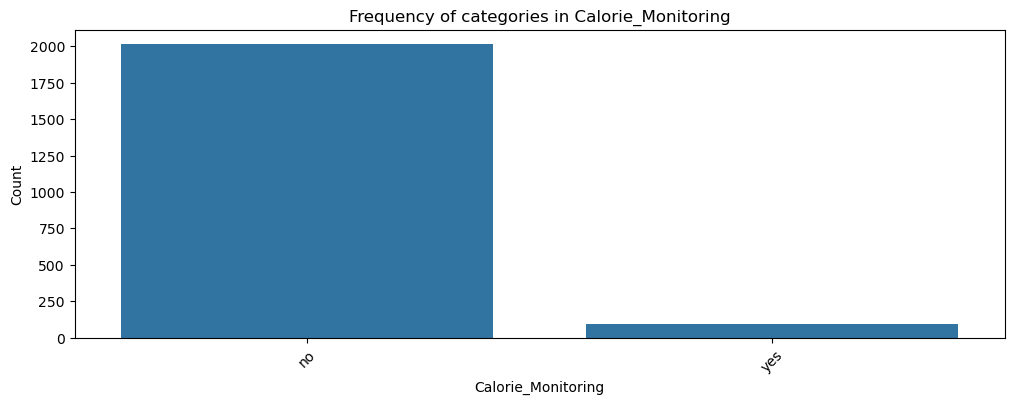

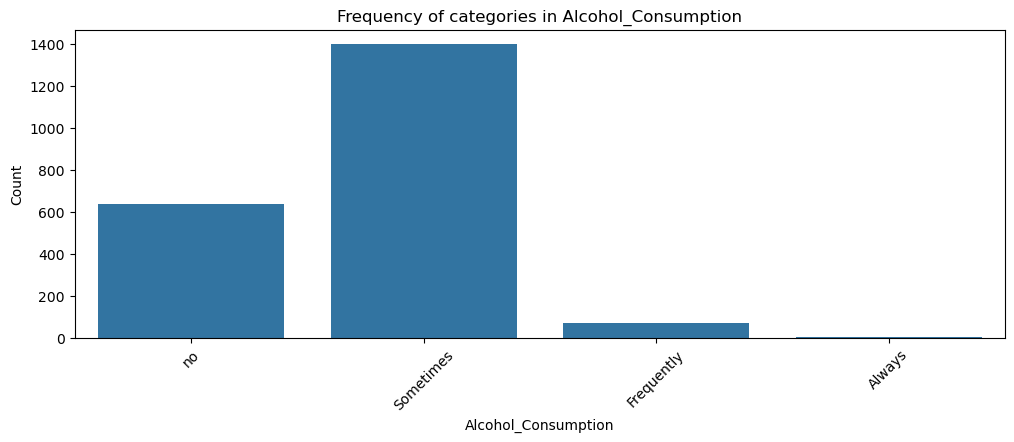

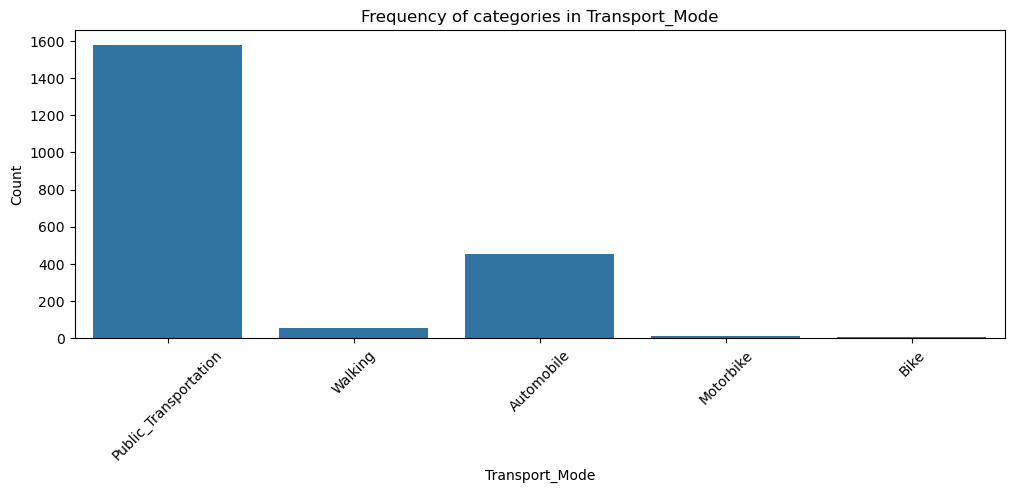

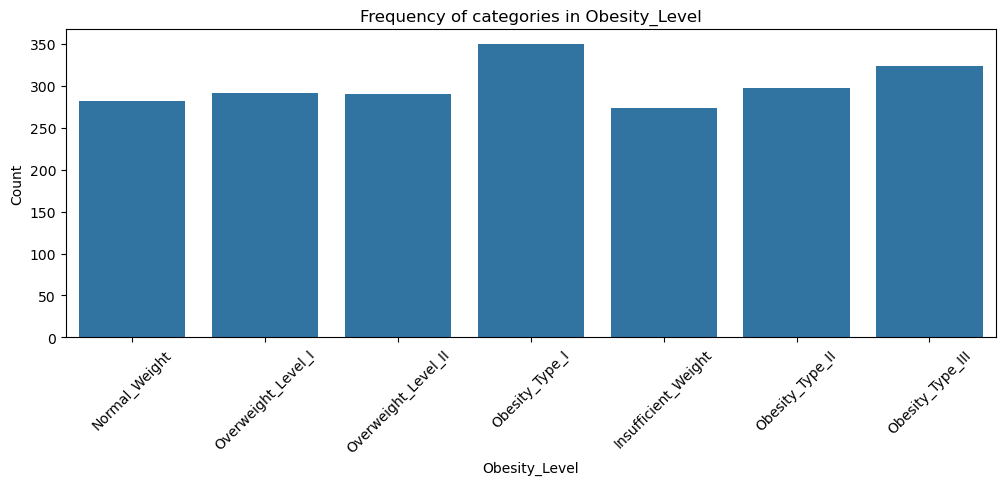

In [44]:
print("\n Distributions of categorical variables: \n")
for var in (discrete_ordinal_vars + list(var_cat)):
    plt.figure(figsize=(12,4))
    sns.countplot(x=dataset_clean[var])
    plt.title(f"Frequency of categories in {var}")
    plt.xlabel(var)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [45]:
print("\n Correlation matrix:")
corr_matrix = dataset_clean[var_num].corr()
display(corr_matrix)


 Correlation matrix:


,Age,Height,Weight,Main_Meals_Per_Day,Physical_Activity_Frequency
Age,1.000000,-0.024472,0.205404,-0.044218,-0.135487
Height,-0.024472,1.000000,0.461006,0.245038,0.290934
Weight,0.205404,0.461006,1.000000,0.103514,-0.048198
Main_Meals_Per_Day,-0.044218,0.245038,0.103514,1.000000,0.129107
Physical_Activity_Frequency,-0.135487,0.290934,-0.048198,0.129107,1.000000


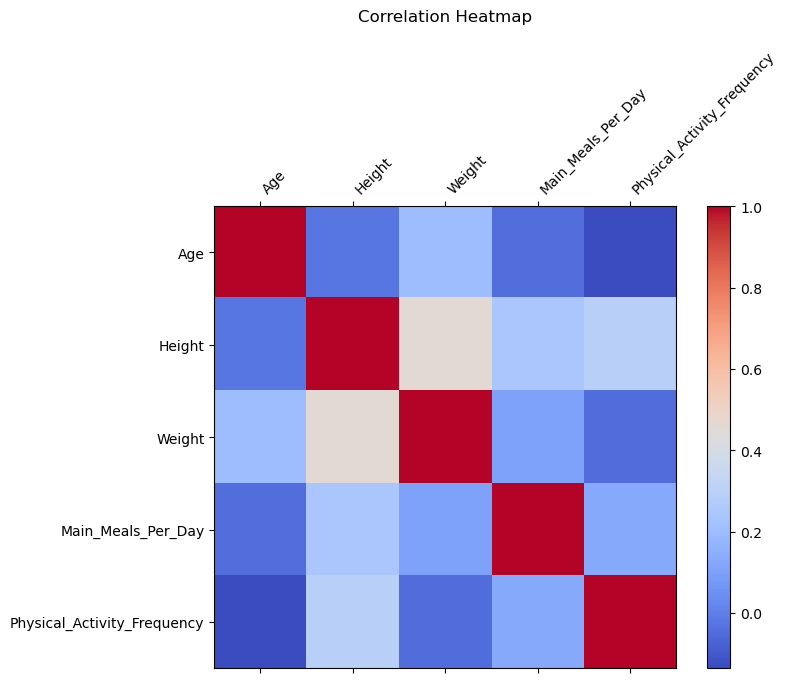

In [46]:
fig, ax = plt.subplots(figsize=(8,6))
cax = ax.matshow(corr_matrix, cmap="coolwarm")
fig.colorbar(cax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)
plt.title("Correlation Heatmap", pad=20)
plt.show()

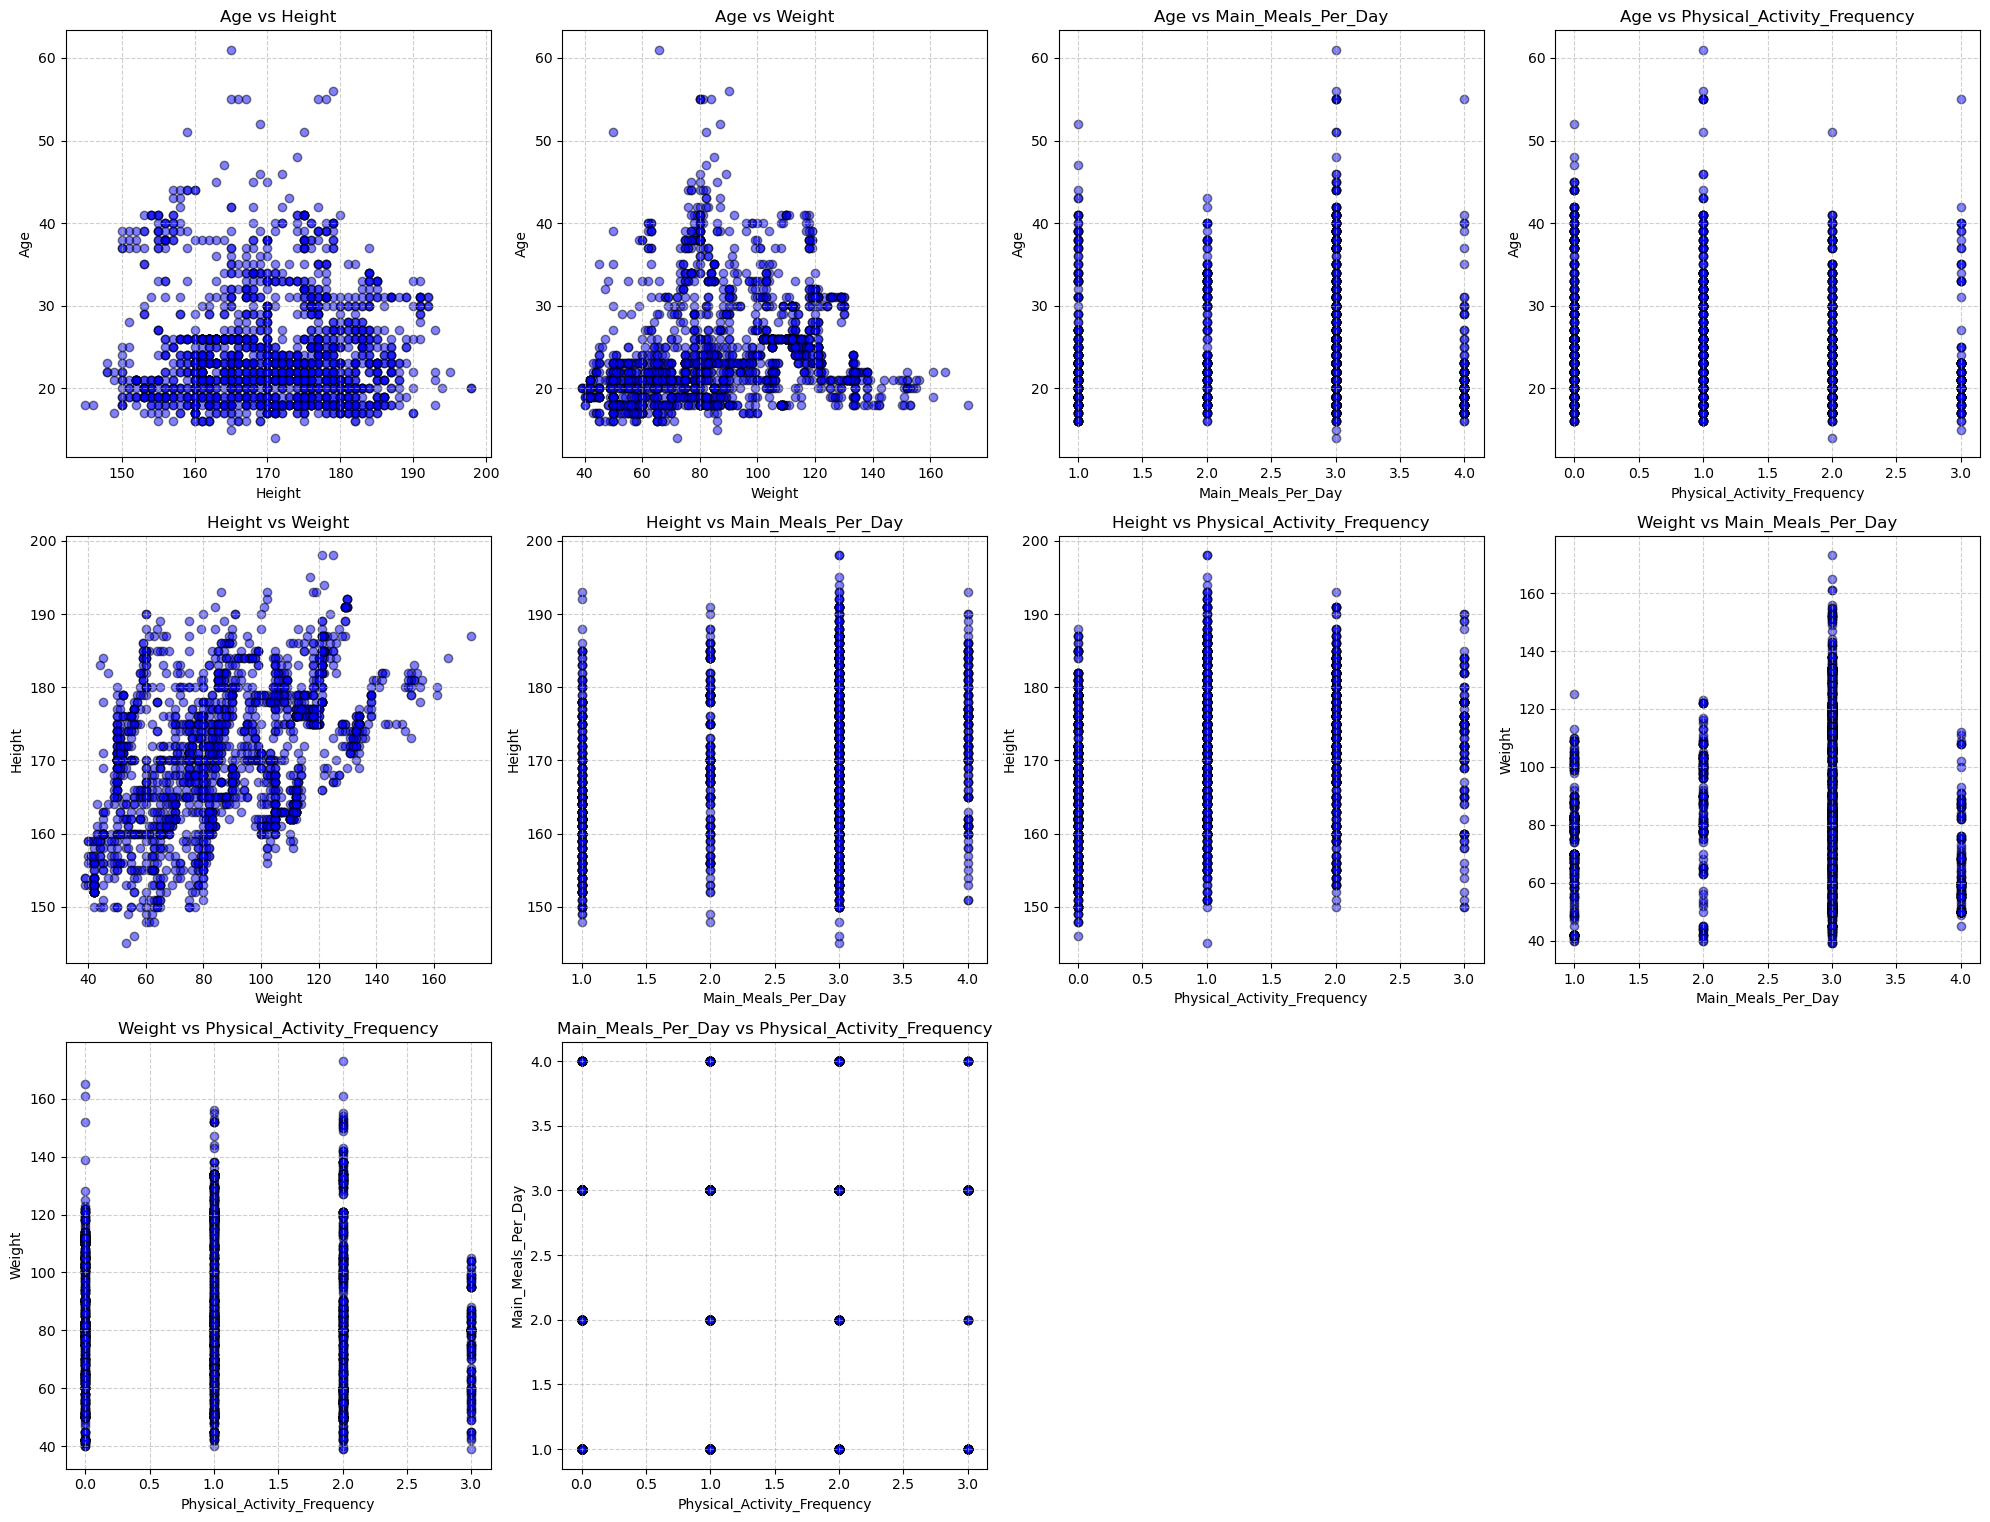

In [47]:
n_vars = len(var_num)

# Calculate total number of combinations
total_plots = n_vars * (n_vars - 1)  # Tutte le coppie diverse

# Create optimal grid
n_cols = min(4, n_vars)  # Maximum 4 columns
n_rows = (total_plots + n_cols - 1) // n_cols  # Calculation of required rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]  # Flatten the array

plot_index = 0
for i, var1 in enumerate(var_num):
    for j, var2 in enumerate(var_num):
        if j > i:  # use only unordered pairs
            ax = axes[plot_index]
            ax.scatter(dataset_clean[var2], dataset_clean[var1],
                       alpha=0.5, color="blue", edgecolors="black")
            ax.set_title(f"{var1} vs {var2}")
            ax.set_xlabel(var2)
            ax.set_ylabel(var1)
            ax.grid(True, linestyle="--", alpha=0.6)
            plot_index += 1

# Hide unused axes
for idx in range(plot_index, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

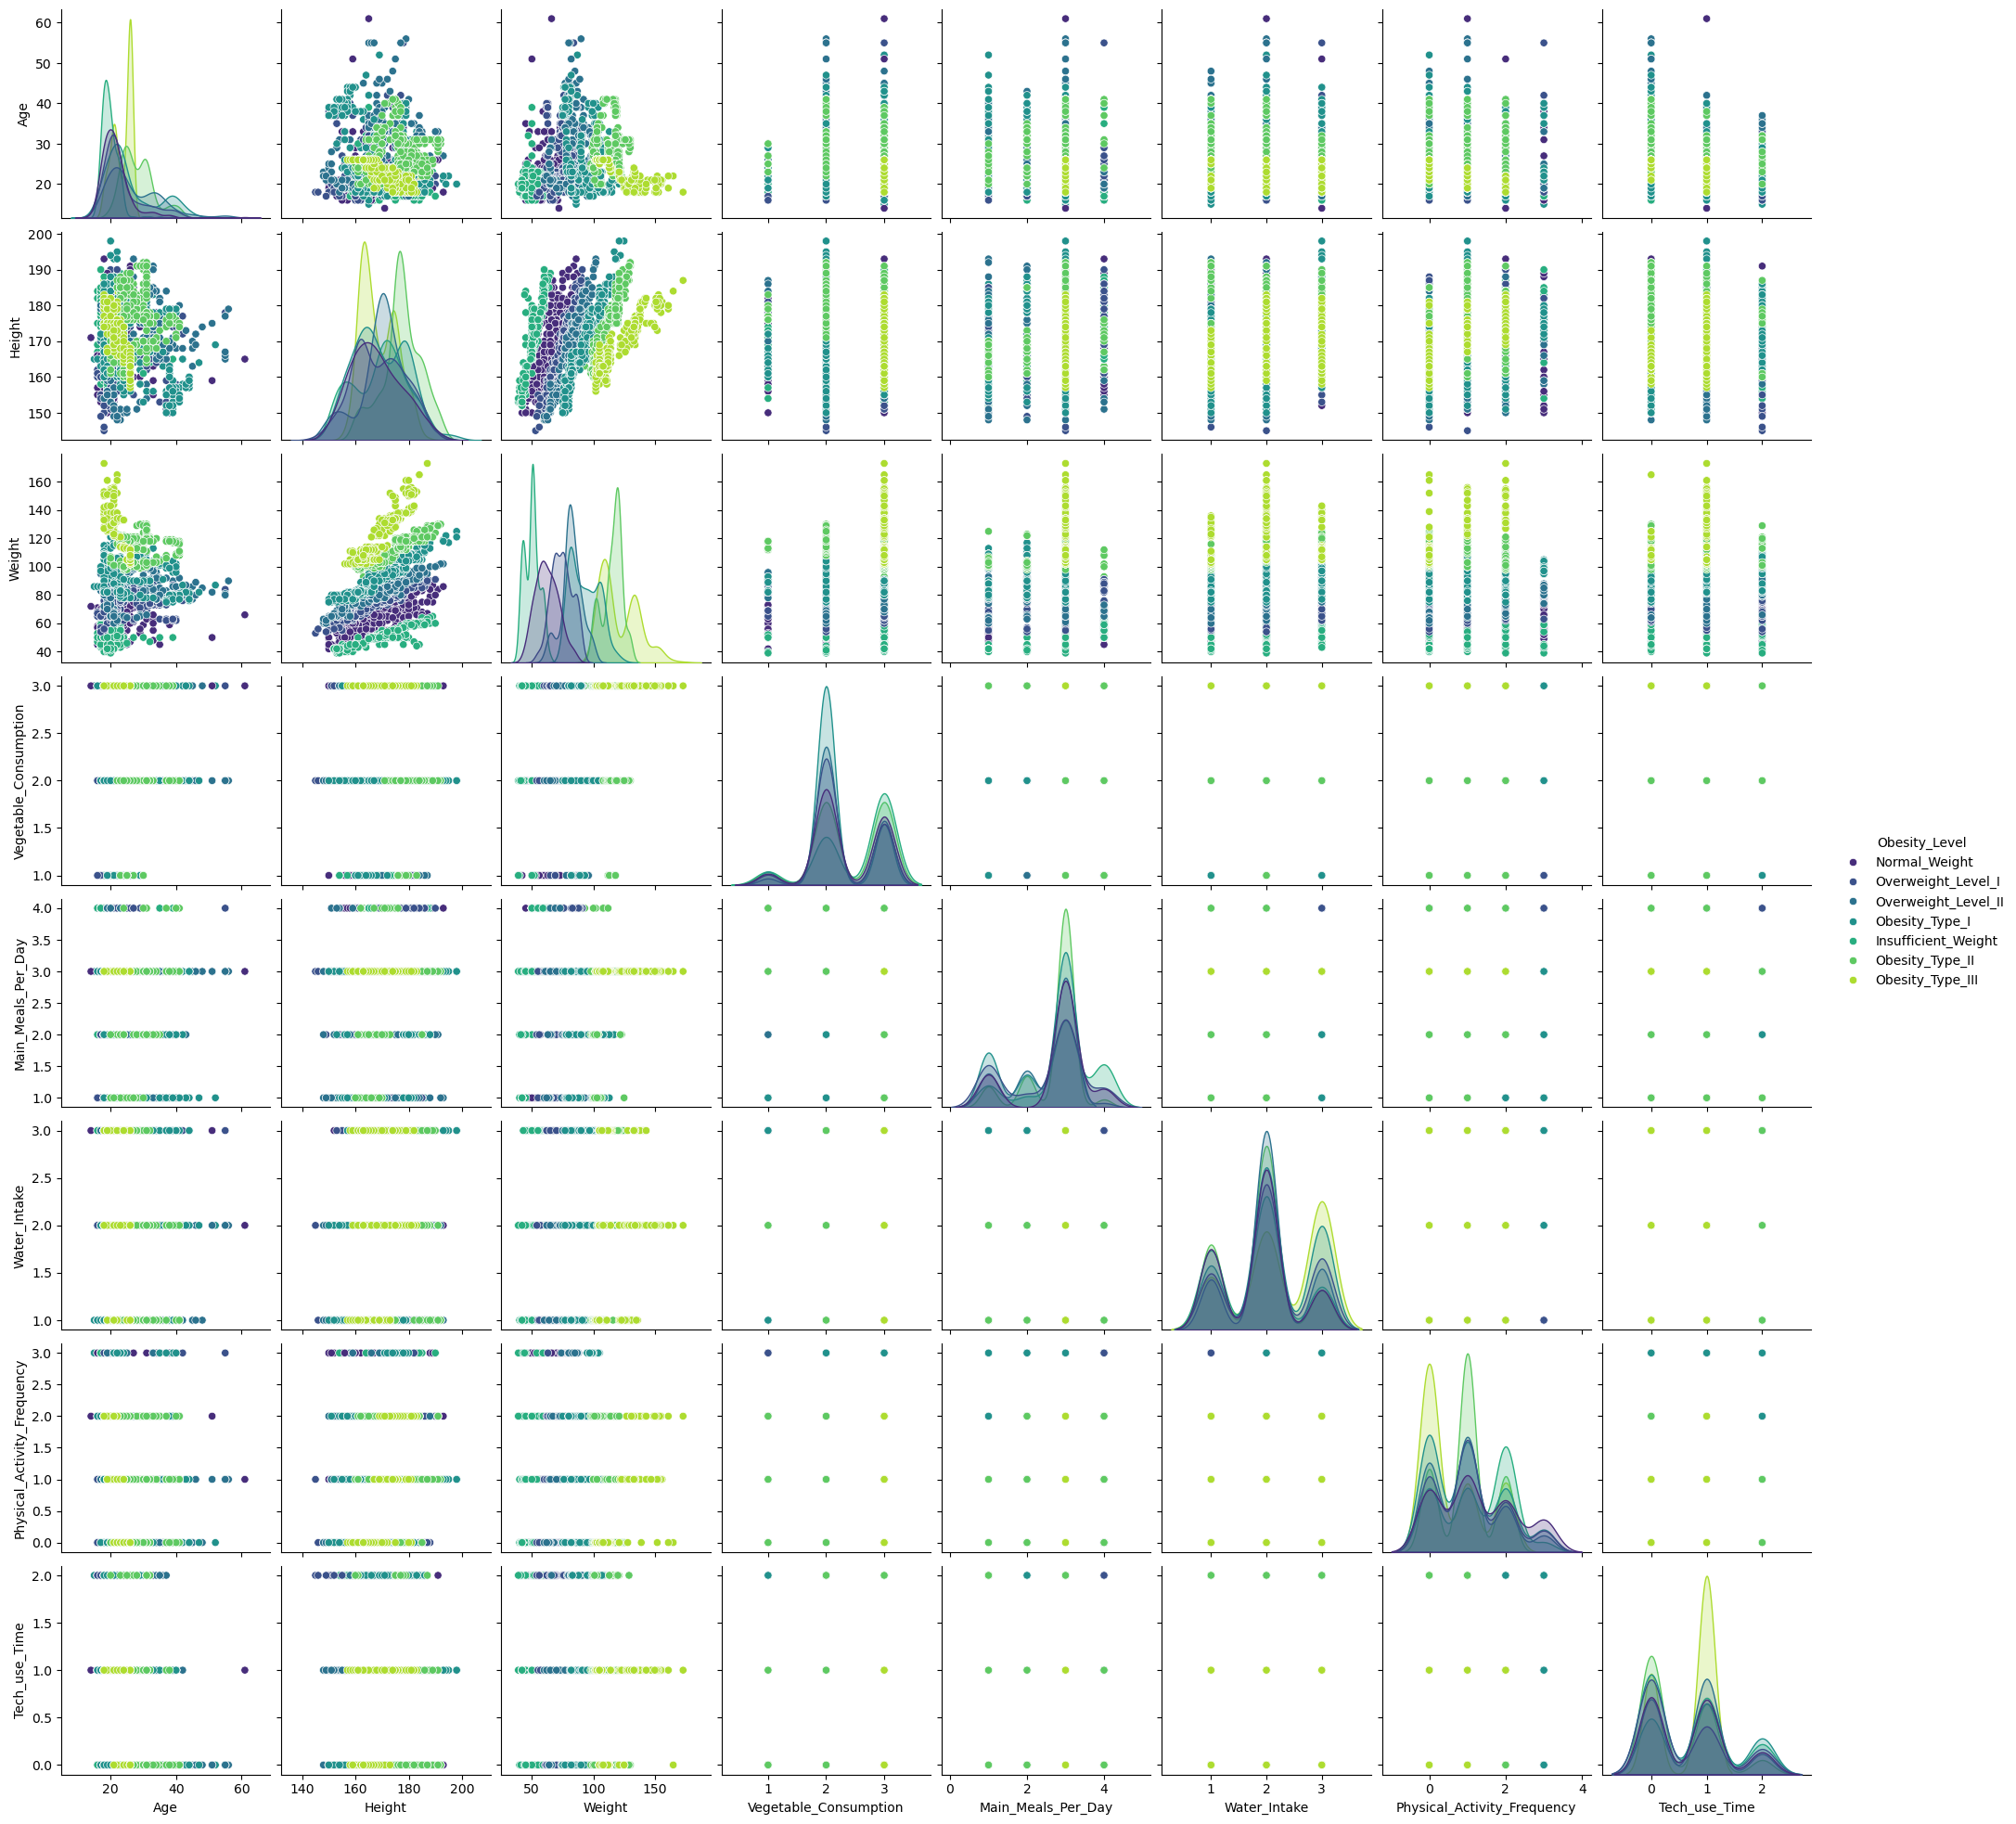

In [54]:
sns.pairplot(dataset_clean, hue = "Obesity_Level", palette = sns.color_palette(palette="viridis", n_colors = 7))

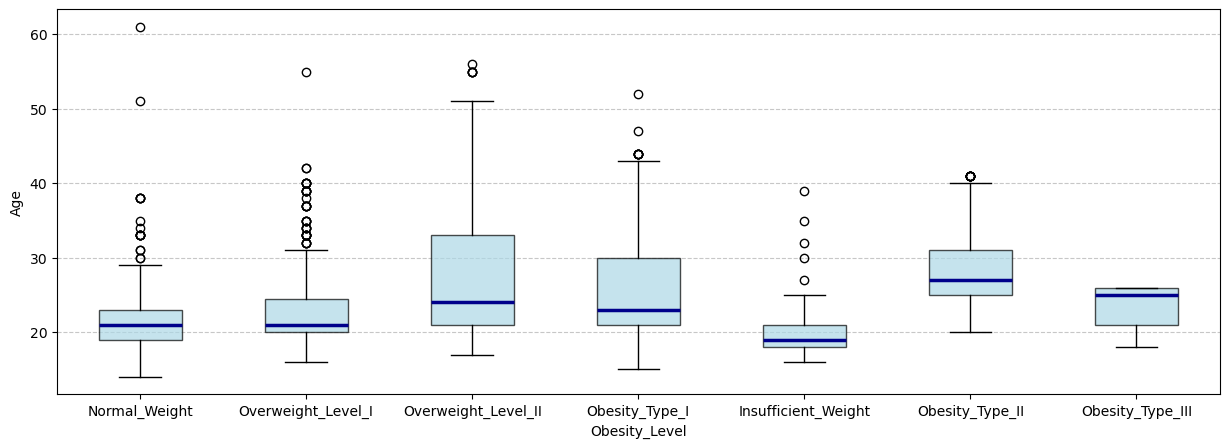

In [55]:
# Comparison of a numerical variable with a categorical variable
# (Example: age distribution for each level of obesity)
target = "Obesity_Level"  # name of the target variable

if target in dataset_clean.columns:
    first_numvar = var_num[0]  # first numerical variable
    categories = dataset_clean[target].unique()
    plt.figure(figsize=(15,5))
    data_to_plot = [dataset_clean[dataset_clean[target] == cat][first_numvar] for cat in categories]
    plt.boxplot(data_to_plot, tick_labels=categories, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha = 0.7), medianprops=dict(color='darkblue', linewidth=2.5)) 
    plt.xlabel(target)
    plt.ylabel(first_numvar)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [57]:
categorical_pairs = [(var_cat[i], var_cat[j])
                     for i in range(len(var_cat))
                         for j in range(i+1, len(var_cat))]

print("\nContingency tables:")
for var1, var2 in categorical_pairs:  
    print(f"\n{var1} vs {var2}")
    display(pd.crosstab(dataset_clean[var1], dataset_clean[var2]))


Contingency tables:

Gender vs family_history_with_overweight


family_history_with_overweight,no,yes
Gender,,
Female,233,808
Male,153,914



Gender vs High_Caloric_Food


High_Caloric_Food,no,yes
Gender,,
Female,143,898
Male,101,966



Gender vs Food_Between_Meals


...

Transport_Mode,Automobile,Bike,Motorbike,Public_Transportation,Walking
Alcohol_Consumption,,,,,
Always,0,0,0,0,1
Frequently,28,0,0,38,3
Sometimes,269,4,6,1091,29
no,158,3,5,450,23



Alcohol_Consumption vs Obesity_Level


Obesity_Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Alcohol_Consumption,,,,,,,
Always,0,1,0,0,0,0,0
Frequently,1,18,13,2,0,16,19
Sometimes,156,157,172,224,323,224,143
no,117,106,165,71,1,51,128



Transport_Mode vs Obesity_Level


Obesity_Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Transport_Mode,,,,,,,
Automobile,46,43,109,95,1,67,94
Bike,0,4,0,1,0,2,0
Motorbike,0,6,3,0,0,1,1
Public_Transportation,222,197,236,200,323,212,189
Walking,6,32,2,1,0,9,6


## 4.1) 

In [ ]:
dataset_clean = dataset_clean.copy()
bin_categoriche = ["Gender", "family_history_with_overweight", "High_Caloric_Food", "SMOKE", "Calorie_Monitoring"]
label_encoders = {}

for var in bin_categoriche:
    le = LabelEncoder()
    dataset_clean[var] = le.fit_transform(dataset_clean[var])
    label_encoders[var] = le
    print(f"{var}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

In [ ]:
multi_categoriche = ["Transport_Mode"]
dataset_clean = pd.get_dummies(dataset_clean, columns=multi_categoriche, prefix=multi_categoriche, dtype = int)

print(f"\nSize after one-hot encoding: {dataset_clean.shape}")

In [ ]:
# ORDINAL variables (they have a natural order)
var_ordinali = {
    "Food_Between_Meals": ["no", "Sometimes", "Frequently", "Always"],
    "Alcohol_Consumption": ["no", "Sometimes", "Frequently", "Always"],
    "Obesity_Level": ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]
}

for var, order in var_ordinali.items():
    dataset_clean[var] = dataset_clean[var].astype("category")
    dataset_clean[var] = dataset_clean[var].cat.set_categories(order, ordered=True)
    dataset_clean[var] = dataset_clean[var].cat.codes
dataset_clean


The inclusion of the target variable during the application of PCA would constitute a methodological error, since PCA is an unsupervised algorithm which, if it included the target, would treat it as any other independent feature. <br> This would mean that the data transformation would also seek to maximise the variance of the target variable itself, contaminating the dimensional reduction process.

In [ ]:
# 4. SEPARATION FEATURES AND TARGETS
print("\nDATA PREPARATION FOR PCA:")

var_target = "Obesity_Level"
# Features for PCA (excluding the target)
features_pca = [var for var in dataset_clean.columns if var != var_target]

X = dataset_clean[features_pca]
y = dataset_clean[var_target]  # Original target

print(f"Number of features for PCA: {len(features_pca)}")
print(f"Shape of X: {X.shape}")

In [ ]:
#Standardization of numerical variables
print("\nSCALING OF THE FEATURES:")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Statistics before scaling:")
print(pd.DataFrame(X, columns=features_pca).describe().loc[["mean", "std"]].round(2))
print("\n")
print("\nStatistics after scaling:")
print(pd.DataFrame(X_scaled, columns=features_pca).describe().loc[["mean", "std"]].round(2))

In [ ]:
print("\nPRINCIPAL COMPONENT ANALYSIS (PCA):")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Analysis of explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance by component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {var:.4f} ({cum_var:.4f} cumulative)")

In [ ]:
# Detailed analysis for 80%
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f"MAIN RESULT:")

print(f"To explain at least 80% of the variance, we need {n_components_80} main components")
print(f"Cumulative variance with {n_components_80} components: {cumulative_variance[n_components_80-1]:.2%}")

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
feature_names = dataset_clean.columns.tolist()
obesity_categories = dataset_clean["Obesity_Level"]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, "ro-")
plt.axhline(y=0.80, color="b", linestyle="--", label="80% variance")
plt.axvline(x=n_components_80, color="g", linestyle="--", label=f'{n_components_80} componenti')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative variance")
plt.legend()
plt.grid(True)
plt.show()

Effective reduction: **-40%** dimensions while maintaining **80%** information

Balanced structure: No component too dominant

Regular progression: Gradual decrease in variance

Informative data: Prime components explain significant variance

In [ ]:
plt.figure(figsize=(10,10))
ax = plt.gca()

# Draw the unit circle
circle = plt.Circle((0, 0), 1, color="blue", fill=False, linestyle="-", alpha=1)
ax.add_artist(circle)

loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_indices = np.argsort(loading_magnitudes)

# Plot loading vectors
for i in top_indices:
    x, y = loadings[i, 0], loadings[i, 1]
    feature_name = feature_names[i]
    
    ax.arrow(0, 0, x, y, color= "red", alpha=0.7, head_width=0.03, head_length=0.03, linewidth=1.5)
    ax.text(x * 1.15, y * 1.15, feature_name, fontsize=9, ha="center", va="center", color="black", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Ax settings
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color="gray", alpha=0.4)
ax.axvline(0, color="gray", alpha=0.4)
ax.set_title("Correlation Circle - Loading Vectors")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,10))
ax2 = plt.gca()

# Scatter plot of PCA scores (observations)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, color="blue", edgecolor="black")

# Add variable loading vectors on the same plot (optional)
for i in top_indices:
    x, y = loadings[i, 0] * max(X_pca[:,0]), loadings[i, 1] * max(X_pca[:,1])  # rescale loadings
    feature_name = feature_names[i]
    
   
    ax2.arrow(0, 0, x, y, color = "red", alpha=0.5, head_width=0.1)
    ax2.text(x * 1.15, y * 1.15, feature_name, fontsize=9, ha="center", va="center", color= "black",bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax2.set_title("Biplot - Observations and Variables")
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
ax2.axhline(0, color="gray", alpha=0.4)
ax2.axvline(0, color="gray", alpha=0.4)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### K-MEANS 

In [ ]:
dataset_pca = pd.DataFrame(X_pca[:,:2], columns=["PC1", "PC2"])
display(dataset_pca.head())

In [ ]:
#ELBOW METHOD
inertia = []
K = range(2,10)

for k in K:
    km = KMeans(n_clusters=k, init = "k-means++", random_state=42)
    km.fit(dataset_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, inertia, "ro-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()


In [ ]:
for k in K:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    clusters = kmeans.fit_predict(dataset_pca)
    silhouette_avg = silhouette_score(dataset_pca, clusters)
    print("For n_clusters =", k, "The average silhouette_score is :", silhouette_avg)

In [ ]:
k = 3 # this is where the "elbow" is formed

kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(dataset_pca) #only the first two components

plt.figure(figsize=(16,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=80, cmap = "tab10", edgecolor="black", linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering using the k-means method on the first two PC")
plt.show()

In [ ]:
centroids = kmeans.cluster_centers_.T # coordinates of cluster
display(centroids)

In [ ]:
dataset_pca["clusters"] = clusters

colors = ["yellow", "pink", "lightblue"]

fig, ax = plt.subplots(figsize=(16, 6))

for k in range(0, 3):
    sns.scatterplot(x=dataset_pca["PC1"][dataset_pca.clusters == k], y=dataset_pca["PC2"][dataset_pca.clusters == k], color=colors[k], label="Cluster {}".format(k+1), s=100)

ax.scatter(centroids[0][:], centroids[1][:], marker="X", s=100, color="black", label="Centroids")
ax.set_title("K-means Clustering with 3 clusters")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.legend()
plt.show()

In [ ]:
kmeans.inertia_

In [ ]:
dataset_pca.drop(columns=["clusters"], inplace=True)
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
random_states = [15, 65, 73, 60, 10, 42]
for i in range(1, 7):
    kmeans = KMeans(n_clusters=3, n_init=1, init="random", random_state=random_states[i-1])
    kmeans.fit(dataset_pca) 
    dataset_pca["clusters"] = kmeans.labels_

    for k in range(0, 3):
        sns.scatterplot(x=dataset_pca["PC1"][dataset_pca.clusters == k], y=dataset_pca["PC2"][dataset_pca.clusters == k], color=colors[k], s=50, ax=ax[(i-1)//3, (i-1)%3],  edgecolor="black")
    
    ax[(i-1)//3, (i-1)%3].set_title(kmeans.inertia_)


plt.show()

In [ ]:
dataset_clean["clusters"] = clusters
dataset_clean.groupby("clusters").mean()

## 5) Summary and Interpretation
The dataset analysed contains 2,114 observations and 17 variables, with information on gender, age, height, weight, eating habits and physical activity, alcohol consumption, transport use, and a target variable relating to obesity levels. <br>
The number of missing values is very low (approximately 0–1%), relating to 6 observations, confirming the quality of the dataset. <br>
From the analysis conducted, we can state that the variables that show clear differences within the groups created refer to daily behaviours that therefore strongly influence the level of obesity. The variables in question are 'frequency of physical activity', 'type of transport used' and 'eating habits'. <br> The variable 'family history of overweight' also has a strong influence on the level of obesity, highlighting the importance of genetics. <br> We can obviously see that, in general, increasing age corresponds to a less favourable physical condition.